# Tunable compliance — emergent grasps

## In-hand manipulation

The hand closes to a PC1 grasp and two asymmetric stiffness configurations are applied:
**Stiff Thumb** (Side B = thumb+index+middle at $K_\mathrm{high}$, Side A = pinky+ring at $K_\mathrm{low}$) and **Soft Thumb** (sides swapped).
The spring length is the task-spring elongation $\|\Delta p\|$ from the PC1 reference fingertip position.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys
from pathlib import Path

sys.path.insert(0, os.path.join('../../'))
from plot_config import draw_radar

FINGERTIPS   = ['thumb', 'index', 'middle', 'ring', 'pinky']
PHASES       = ['asym_a', 'asym_b']
PHASE_LABELS = {'asym_a': 'Stiff Thumb', 'asym_b': 'Soft Thumb'}
PHASE_COLORS = {'asym_a': '#E69F00', 'asym_b': '#D55E00'}

SIDE_A = ['pinky', 'ring']             # K_low in Stiff Thumb, K_high in Soft Thumb
SIDE_B = ['thumb', 'index', 'middle']  # K_high in Stiff Thumb, K_low in Soft Thumb

OUTPUT_INHAND = os.path.join('outputs', 'inhand_manipulation')
os.makedirs(OUTPUT_INHAND, exist_ok=True)


def load_inhand():
    path = Path(OUTPUT_INHAND) / 'inhand_run.csv'
    return pd.read_csv(path) if path.exists() else None


df = load_inhand()
if df is None:
    print('No data — run inhand_manipulation.py first.')
else:
    print(df['phase'].value_counts().to_dict())

{'uniform': 96, 'asym_b': 94, 'asym_a': 92}


### Spring length per finger

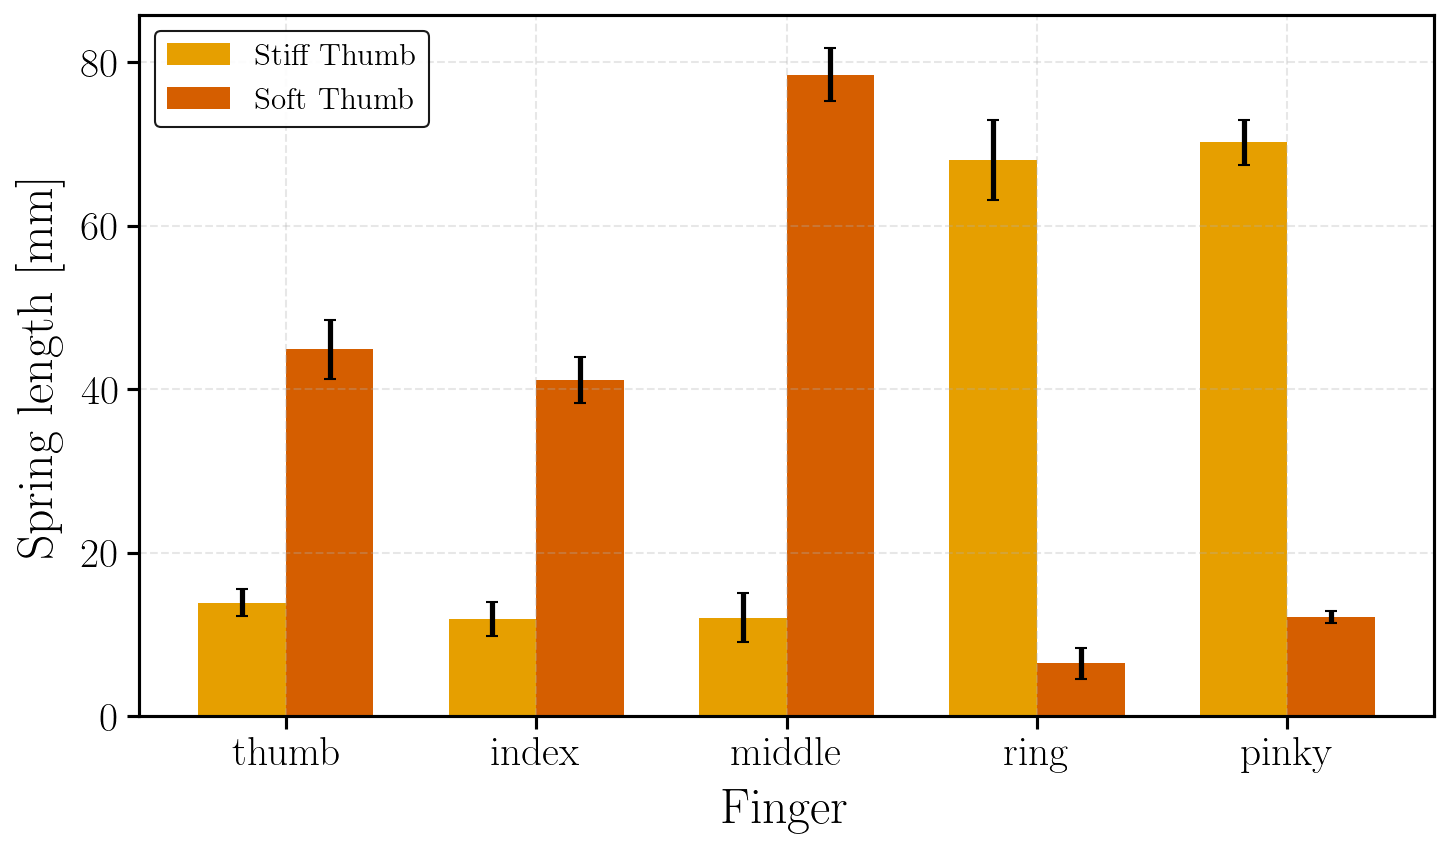

In [16]:
fig, ax = plt.subplots()
x = np.arange(len(FINGERTIPS))
width = 0.35

for i, phase in enumerate(PHASES):
    means, stds = [], []
    for f in FINGERTIPS:
        if df is not None:
            rows = df[df['phase'] == phase]
            mag  = np.sqrt(rows[f'disp_{f}_x_m']**2 +
                           rows[f'disp_{f}_y_m']**2 +
                           rows[f'disp_{f}_z_m']**2) * 1e3
            means.append(float(mag.mean()))
            stds.append(float(mag.std()))
        else:
            means.append(0.0); stds.append(0.0)
    ax.bar(x + i * width, means, width, yerr=stds, capsize=3,
           label=PHASE_LABELS[phase], color=PHASE_COLORS[phase])

ax.set_xticks(x + width / 2)
ax.set_xticklabels(FINGERTIPS)
ax.set_xlabel('Finger')
ax.set_ylabel('Spring length [mm]')
ax.legend(fontsize='small')
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_INHAND, 'inhand_spring_length.pdf'), bbox_inches='tight')
plt.show()

Finger spring lengths (mm):


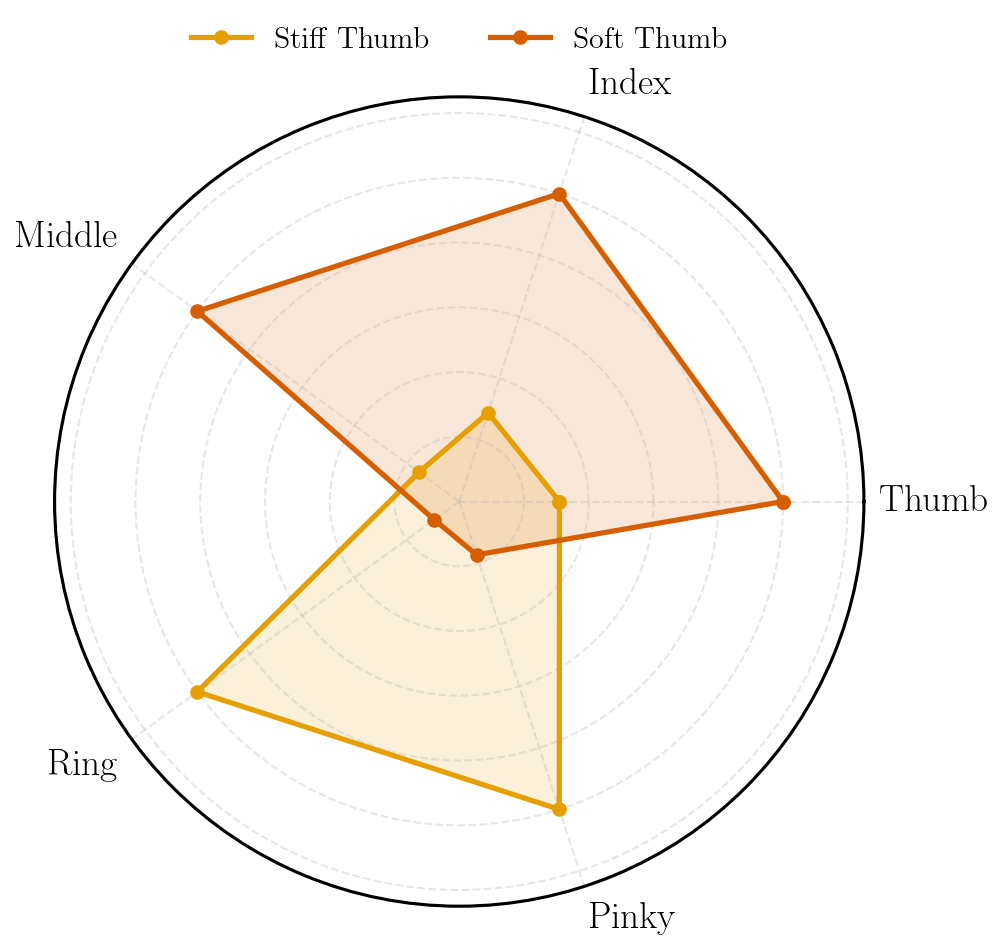

(<Figure size 1050x1050 with 1 Axes>, <PolarAxes: >)

In [17]:
traces = []
for phase in PHASES:
    means = []
    for f in FINGERTIPS:
        if df is not None:
            rows = df[df['phase'] == phase]
            mag  = np.sqrt(rows[f'disp_{f}_x_m']**2 +
                           rows[f'disp_{f}_y_m']**2 +
                           rows[f'disp_{f}_z_m']**2) * 1e3
            means.append(float(mag.mean()))
        else:
            means.append(0.0)
    traces.append({'label': PHASE_LABELS[phase], 'values': means, 'color': PHASE_COLORS[phase]})

print("Finger spring lengths (mm):")
draw_radar(
    [f.capitalize() for f in FINGERTIPS],
    traces,
    os.path.join(OUTPUT_INHAND, 'radar_spring_length.pdf'),
)

### Contact force magnitude per finger

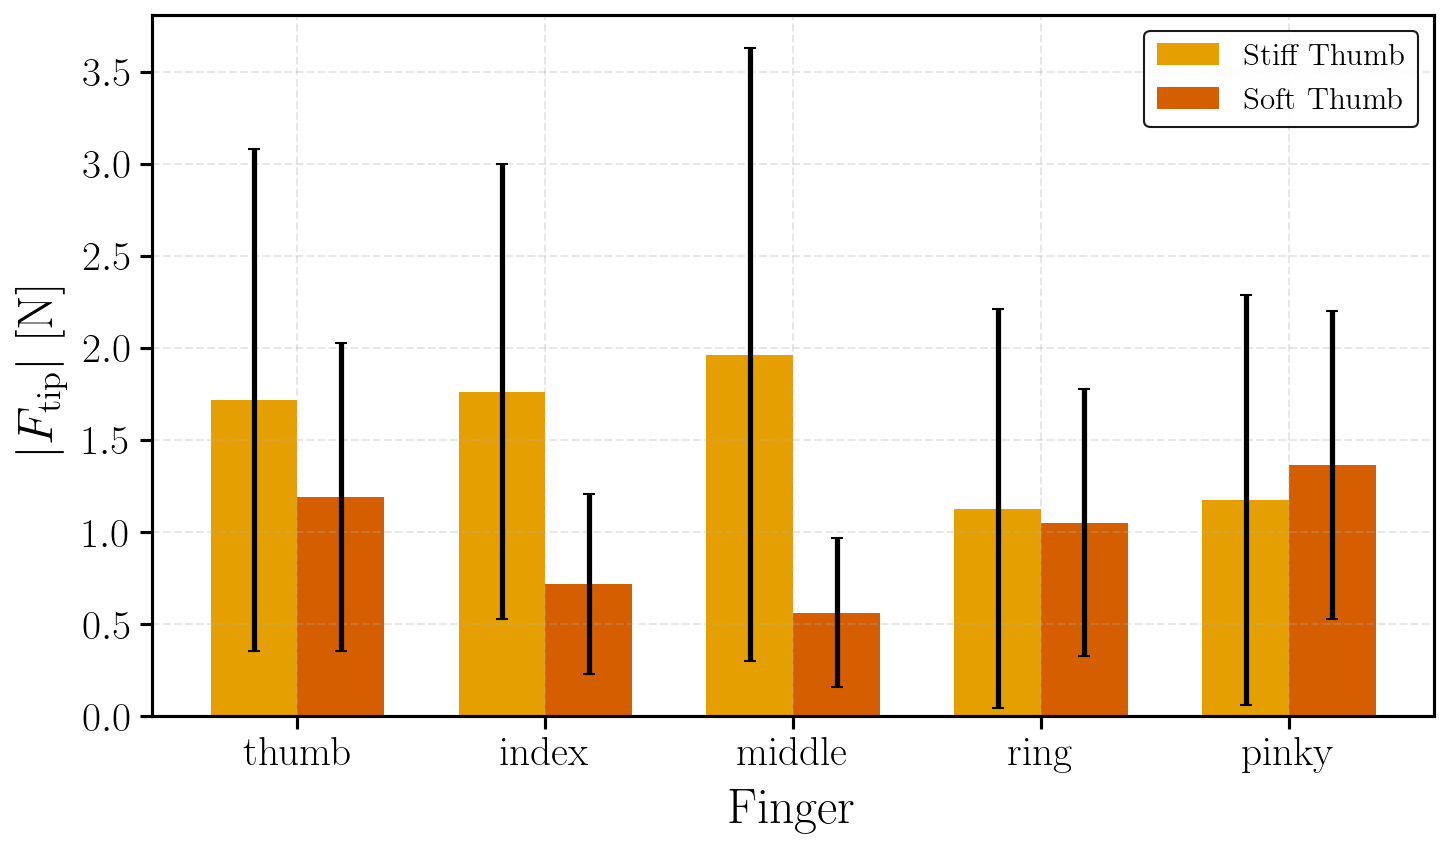

In [18]:
fig, ax = plt.subplots()
x = np.arange(len(FINGERTIPS))
width = 0.35

for i, phase in enumerate(PHASES):
    means, stds = [], []
    for f in FINGERTIPS:
        col = f'force_1st_{f}_mag_N'
        if df is not None and col in df.columns:
            rows = df[df['phase'] == phase]
            means.append(float(rows[col].mean()))
            stds.append(float(rows[col].std()))
        else:
            means.append(0.0); stds.append(0.0)
    ax.bar(x + i * width, means, width, yerr=stds, capsize=3,
           label=PHASE_LABELS[phase], color=PHASE_COLORS[phase])

ax.set_xticks(x + width / 2)
ax.set_xticklabels(FINGERTIPS)
ax.set_xlabel('Finger')
ax.set_ylabel(r'$|F_{\mathrm{tip}}|$ [N]')
ax.legend(fontsize='small')
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_INHAND, 'inhand_force.pdf'), bbox_inches='tight')
plt.show()

Finger contact forces (N):


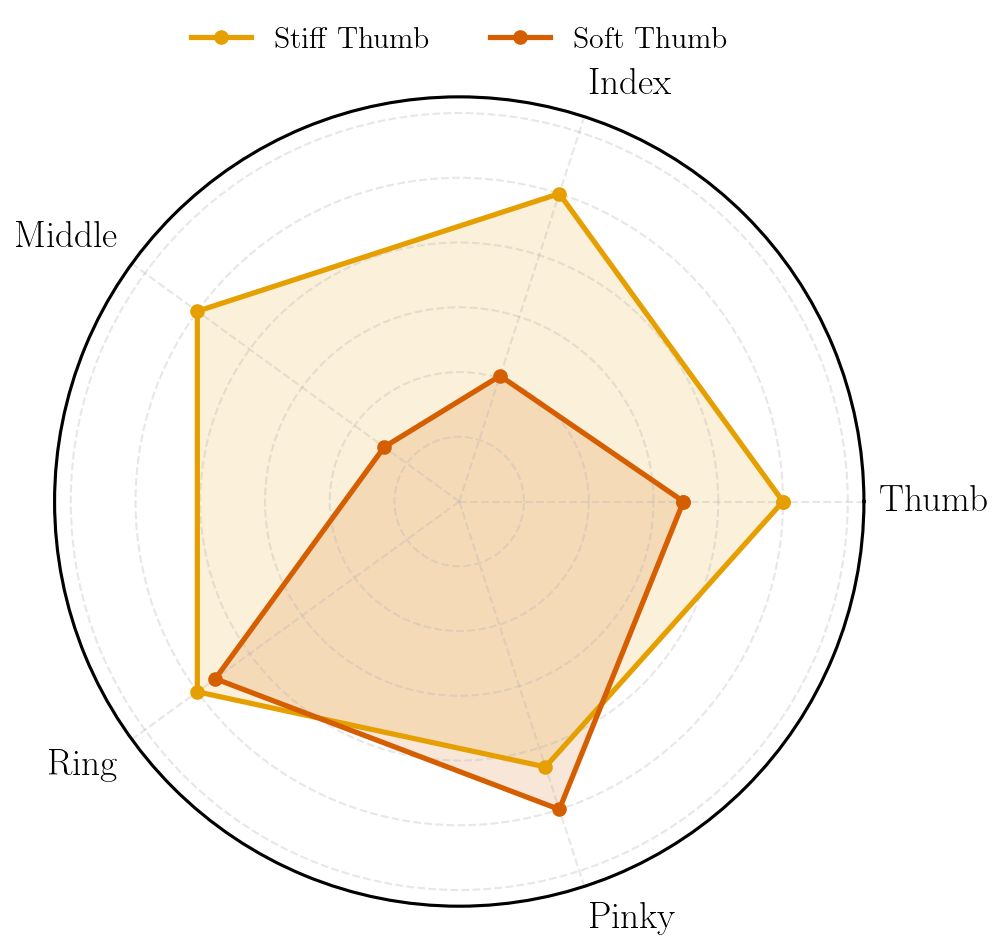

(<Figure size 1050x1050 with 1 Axes>, <PolarAxes: >)

In [19]:
traces = []
for phase in PHASES:
    means = []
    for f in FINGERTIPS:
        col = f'force_1st_{f}_mag_N'
        if df is not None and col in df.columns:
            rows = df[df['phase'] == phase]
            means.append(float(rows[col].mean()))
        else:
            means.append(0.0)
    traces.append({'label': PHASE_LABELS[phase], 'values': means, 'color': PHASE_COLORS[phase]})

print("Finger contact forces (N):")
draw_radar(
    [f.capitalize() for f in FINGERTIPS],
    traces,
    os.path.join(OUTPUT_INHAND, 'radar_force.pdf'),
)

## Dynamic grasping

The UR5 slides the hand along +X. The hand closes to PC1 at a fixed distance under three stiffness schedules:
**Soft** ($K_\mathrm{soft}$ throughout), **Stiff** ($K_\mathrm{stiff}$ throughout),
**Adaptive** ($K_\mathrm{soft}$ at close, then ramps to $K_\mathrm{stiff}$).

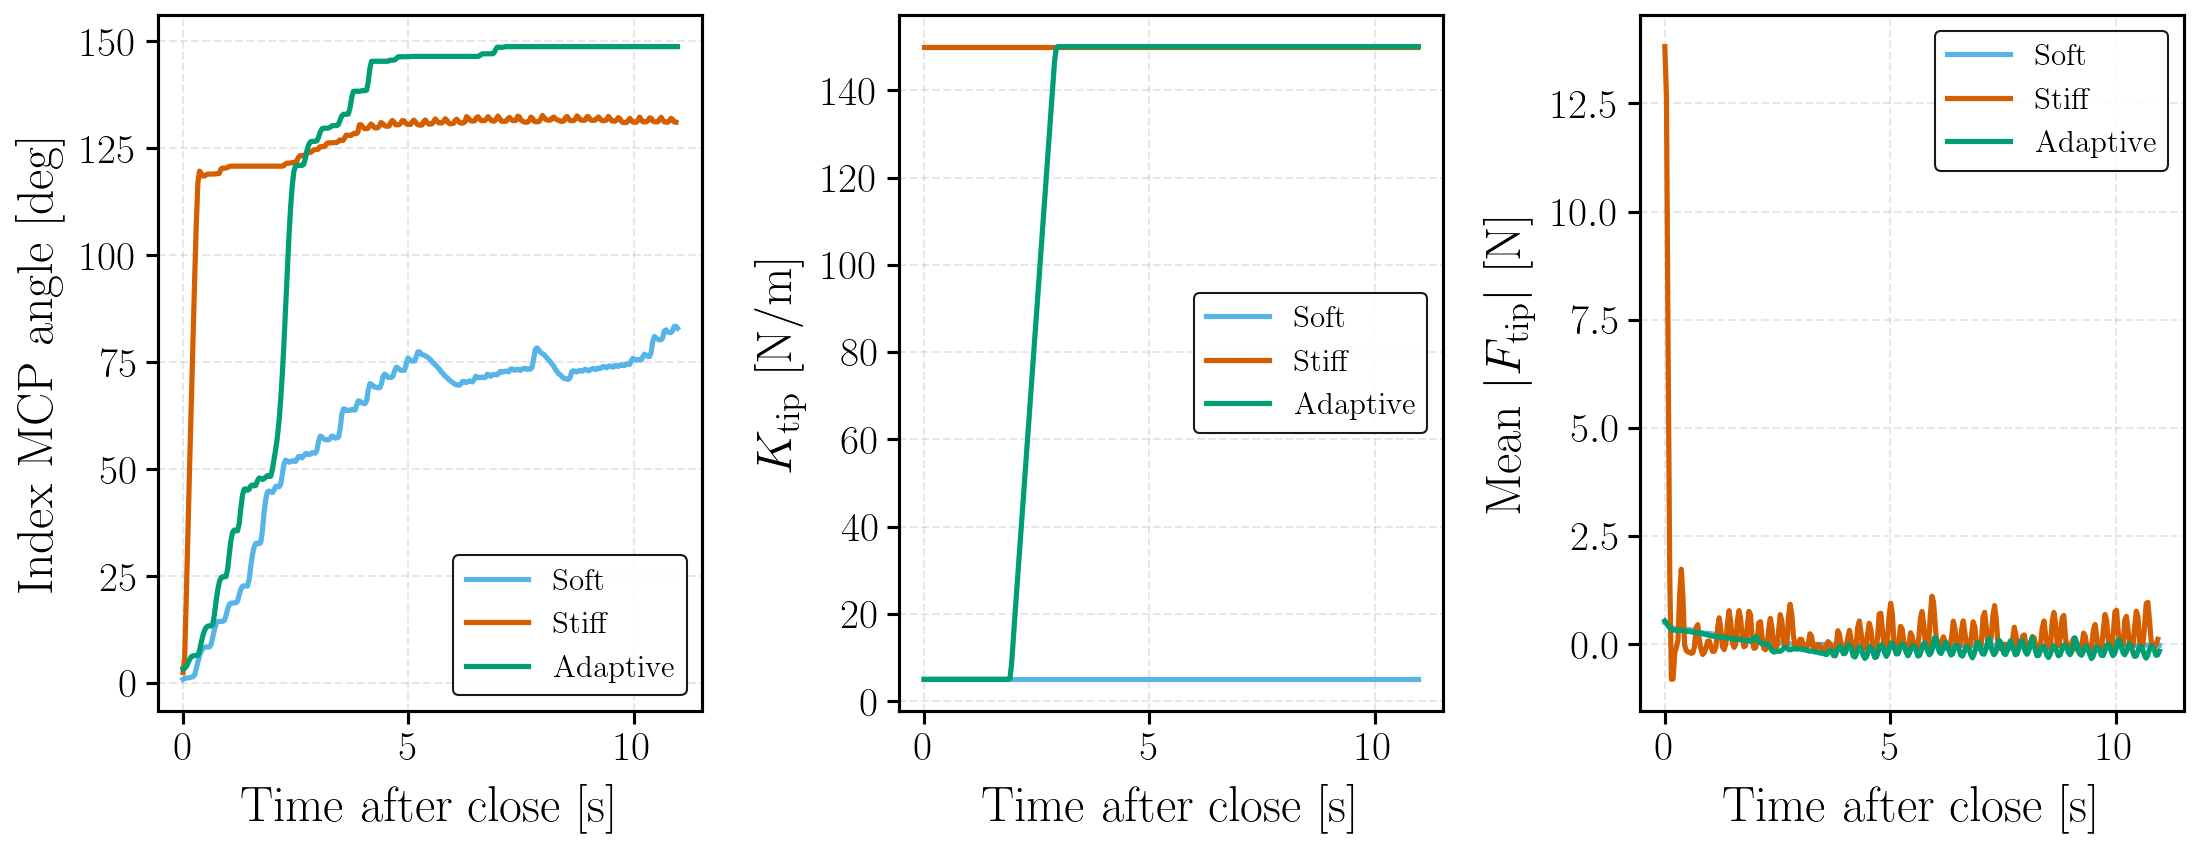

In [20]:
OUTPUT_GRASP = os.path.join('outputs', 'dynamic_grasp')
os.makedirs(OUTPUT_GRASP, exist_ok=True)

CONDITIONS = ['soft', 'stiff', 'adaptive']
COLORS_DG  = {'soft': '#56B4E9', 'stiff': '#D55E00', 'adaptive': '#009E73'}


def load_dynamic(condition):
    path = Path(OUTPUT_GRASP) / f'dynamic_grasp_{condition}.csv'
    return pd.read_csv(path) if path.exists() else None


N_GRID = 300


def interp_trace(arr, n=N_GRID):
    x = np.linspace(0, 1, len(arr))
    return np.interp(np.linspace(0, 1, n), x, arr)


_force_cols = [f'force_{f}_mag_N' for f in FINGERTIPS]

fig, axes = plt.subplots(1, 3, figsize=(plt.rcParams['figure.figsize'][0] * 1.5,
                                        plt.rcParams['figure.figsize'][1]))

for cond, color in COLORS_DG.items():
    df_dg = load_dynamic(cond)
    if df_dg is None or df_dg.empty:
        continue
    closed = df_dg[df_dg['phase'] != 'open']
    if closed.empty:
        continue
    T = np.linspace(0, len(closed) / 30, N_GRID)

    axes[0].plot(T, np.rad2deg(interp_trace(closed['q_7'].to_numpy())),
                 color=color, label=cond.capitalize())
    axes[1].plot(T, interp_trace(closed['k_tip_Npm'].to_numpy()),
                 color=color, label=cond.capitalize())
    if all(c in closed.columns for c in _force_cols):
        mean_force = closed[_force_cols].mean(axis=1).to_numpy()
        axes[2].plot(T, interp_trace(mean_force), color=color, label=cond.capitalize())

for ax, ylabel in zip(axes, [
    'Index MCP angle [deg]',
    r'$K_{\mathrm{tip}}$ [N/m]',
    r'Mean $|F_{\mathrm{tip}}|$ [N]',
]):
    ax.set_xlabel('Time after close [s]')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize='small')

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_GRASP, 'dynamic_grasp_comparison.pdf'), bbox_inches='tight')
plt.show()

### Force distribution at grasp end

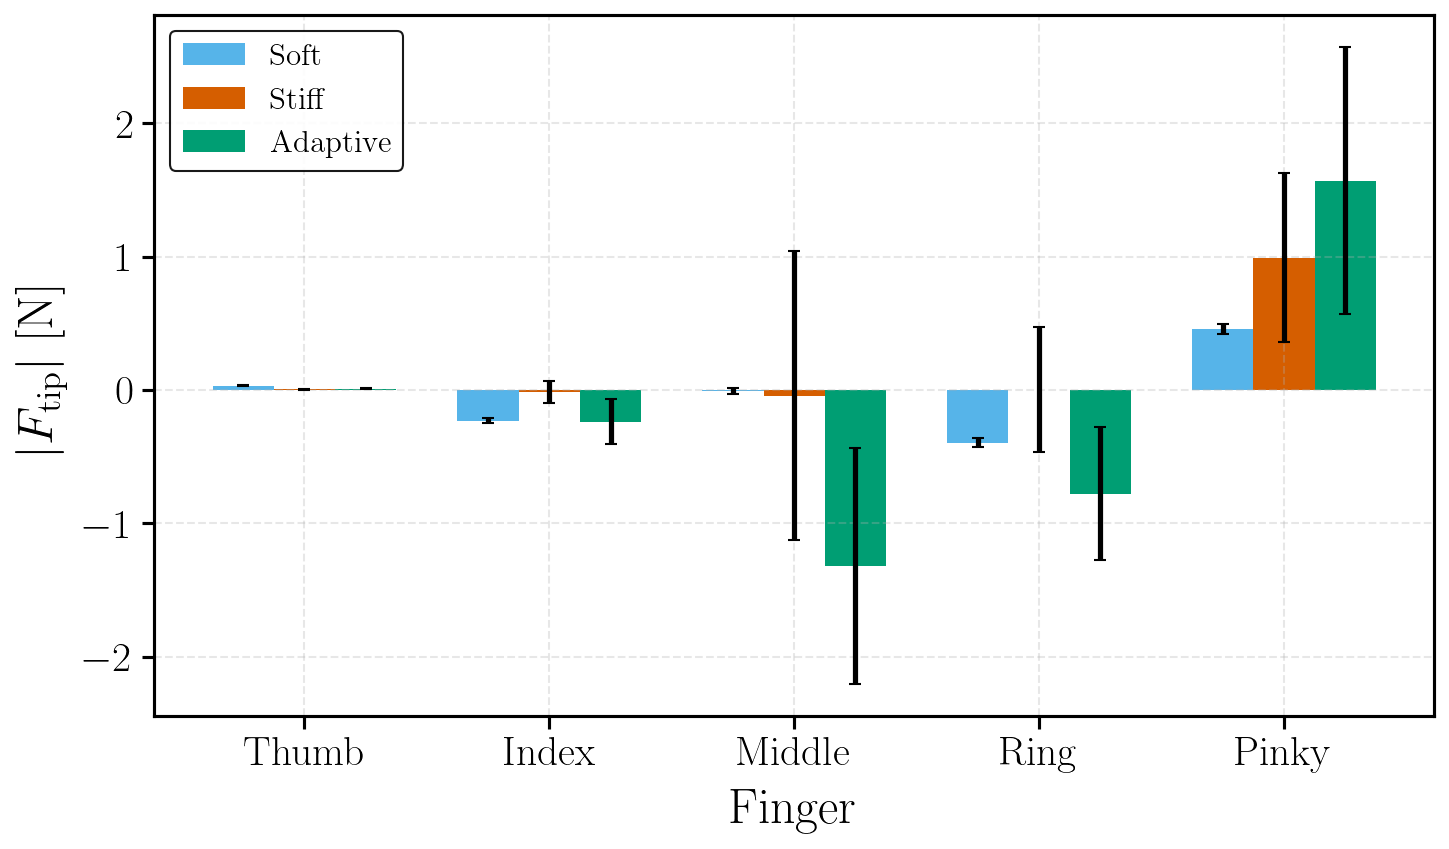

Force distribution at grasp end:


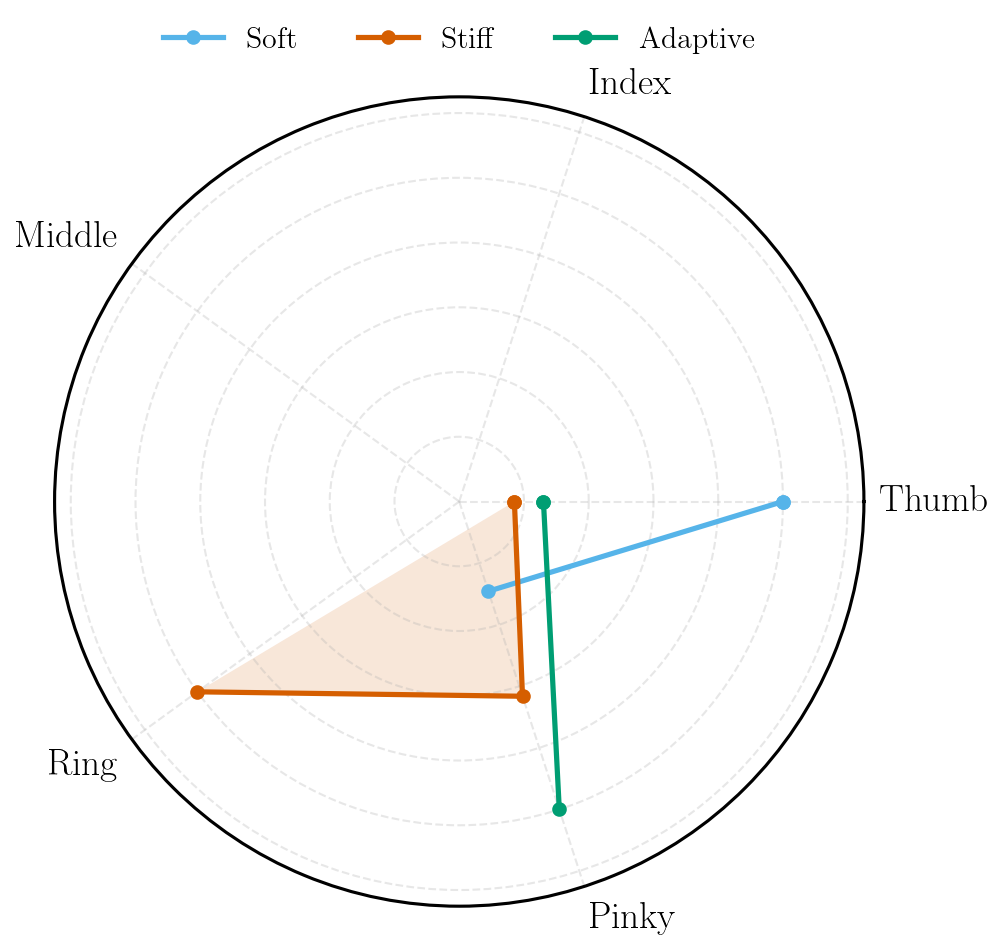

(<Figure size 1050x1050 with 1 Axes>, <PolarAxes: >)

In [21]:
# Per-finger force magnitude averaged over the last 20 % of the 'closed' phase.
x     = np.arange(len(FINGERTIPS))
width = 0.25

fig, ax = plt.subplots()
for i, (cond, color) in enumerate(COLORS_DG.items()):
    df_dg = load_dynamic(cond)
    if df_dg is None or df_dg.empty:
        continue
    closed = df_dg[df_dg['phase'] == 'closed']
    if closed.empty:
        continue
    tail  = closed.tail(max(1, len(closed) // 5))
    means = [float(tail[f'force_{f}_mag_N'].mean()) if f'force_{f}_mag_N' in tail.columns else 0.0
             for f in FINGERTIPS]
    stds  = [float(tail[f'force_{f}_mag_N'].std())  if f'force_{f}_mag_N' in tail.columns else 0.0
             for f in FINGERTIPS]
    ax.bar(x + i * width, means, width, yerr=stds, capsize=3,
           label=cond.capitalize(), color=color)

ax.set_xticks(x + width)
ax.set_xticklabels([f.capitalize() for f in FINGERTIPS])
ax.set_xlabel('Finger')
ax.set_ylabel(r'$|F_{\mathrm{tip}}|$ [N]')
ax.legend(fontsize='small')
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_GRASP, 'dynamic_grasp_force_bar.pdf'), bbox_inches='tight')
plt.show()

traces = []
for cond, color in COLORS_DG.items():
    df_dg = load_dynamic(cond)
    closed = (df_dg[df_dg['phase'] == 'closed'] if df_dg is not None and not df_dg.empty
              else None)
    if closed is not None and not closed.empty:
        tail  = closed.tail(max(1, len(closed) // 5))
        means = [float(tail[f'force_{f}_mag_N'].mean()) if f'force_{f}_mag_N' in tail.columns else 0.0
                 for f in FINGERTIPS]
    else:
        means = [0.0] * len(FINGERTIPS)
    traces.append({'label': cond.capitalize(), 'values': means, 'color': color})

print("Force distribution at grasp end:")
draw_radar(
    [f.capitalize() for f in FINGERTIPS],
    traces,
    os.path.join(OUTPUT_GRASP, 'dynamic_grasp_force_radar.pdf'),
)